In [66]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [67]:
import kagglehub

path = kagglehub.dataset_download(
    "hosammhmdali/house-price-dataset"
)

print("Dataset path:", path)

df = pd.read_csv(path + "/housing.csv")

print("\nDataset Shape:", df.shape)
df.head()


Dataset path: C:\Users\admin\.cache\kagglehub\datasets\hosammhmdali\house-price-dataset\versions\1

Dataset Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [68]:
print(df.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')


In [69]:
print("\nDataset Information:")
df.info()



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [70]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [71]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [72]:
print("\nSummary Statistics:")
print(df.describe())


Summary Statistics:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   

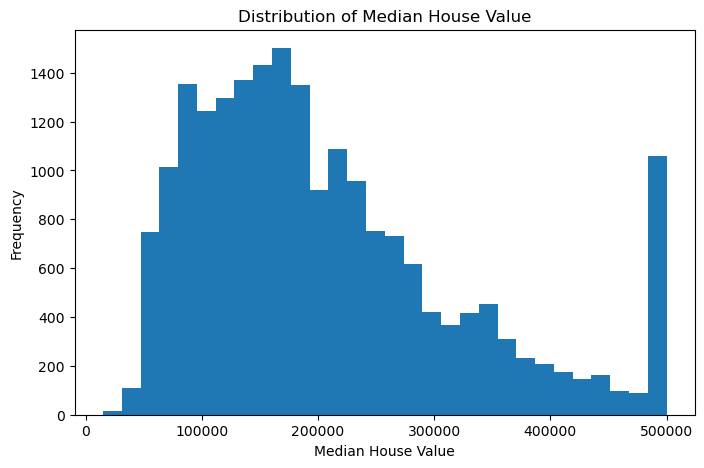

In [73]:

plt.figure(figsize=(8, 5))
plt.hist(df["median_house_value"], bins=30)
plt.title("Distribution of Median House Value")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")
plt.show()


In [74]:
correlation = (
    df.corr(numeric_only=True)["median_house_value"]
    .sort_values(ascending=False)
)

print("\nCorrelation with Median House Value:")
print(correlation)


Correlation with Median House Value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [75]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nRaw Features:")
print(X.head())



X shape: (20640, 9)
y shape: (20640,)

Raw Features:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income ocean_proximity  
0       322.0       126.0         8.3252        NEAR BAY  
1      2401.0      1138.0         8.3014        NEAR BAY  
2       496.0       177.0         7.2574        NEAR BAY  
3       558.0       219.0         5.6431        NEAR BAY  
4       565.0       259.0         3.8462        NEAR BAY  


In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (16512, 9)
Testing shape: (4128, 9)


In [77]:
numeric_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income"]

categorical_features = ["ocean_proximity"]

print("\nNumeric Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


Numeric Features:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']

Categorical Features:
['ocean_proximity']


In [78]:
numeric_pipeline = Pipeline([("imputer",SimpleImputer(strategy="median"))])

categorical_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")),
                                 ("encoder",OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer([("num",numeric_pipeline,numeric_features),
                                  ("cat",categorical_pipeline,categorical_features)])

In [79]:
linear_pipeline = Pipeline([("preprocessor",preprocessor),
                    ("model",LinearRegression())])

linear_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', LinearRegression())])

In [80]:
linear_pred = linear_pipeline.predict(X_test)

In [81]:
linear_mae = mean_absolute_error(y_test,linear_pred)

linear_rmse = np.sqrt(mean_squared_error(y_test,linear_pred))

linear_r2 = r2_score(y_test,linear_pred)

print("\nLINEAR REGRESSION RESULTS")
print("-------------------------")
print("MAE :", linear_mae)
print("RMSE:", linear_rmse)
print("R²  :", linear_r2)



LINEAR REGRESSION RESULTS
-------------------------
MAE : 50670.4892356559
RMSE: 70059.19333925002
R²  : 0.625438267529628


In [82]:
rf_pipeline = Pipeline([("preprocessor",preprocessor),
            ("model",RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1))])

In [83]:
rf_pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('model', RandomForestRegressor(n_jobs=-1, random_state=42))])

In [84]:
rf_pred = rf_pipeline.predict(X_test)

In [85]:
rf_mae = mean_absolute_error(y_test,rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

rf_r2 = r2_score(y_test,rf_pred)

print("\nRANDOM FOREST RESULTS")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)


RANDOM FOREST RESULTS
---------------------
MAE : 31636.34963905039
RMSE: 48977.063518396775
R²  : 0.8169462518407672


In [86]:
comparison = pd.DataFrame({"Model": ["Linear Regression","Random Forest"],
    "MAE": [linear_mae,rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R²": [linear_r2,rf_r2]})

print("\nMODEL COMPARISON")
print("----------------")
print(comparison)


MODEL COMPARISON
----------------
               Model           MAE          RMSE        R²
0  Linear Regression  50670.489236  70059.193339  0.625438
1      Random Forest  31636.349639  48977.063518  0.816946


In [87]:
house_test = X_test.copy()

house_test["median_house_value"] = (y_test.values)

house_test.to_csv("california_house_test.csv",index=False)

print("\nTrustAI test dataset saved:",house_test.shape)


TrustAI test dataset saved: (4128, 10)


In [88]:
rf_small_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=60,
        random_state=42,
        n_jobs=-1
    ))
])

rf_small_pipeline.fit(X_train, y_train)

joblib.dump(
    rf_small_pipeline,
    "house_price_pipeline.joblib",
    compress=3
)

size_mb = os.path.getsize(
    "house_price_pipeline.joblib"
) / (1024 * 1024)

print(f"Model size: {size_mb:.2f} MB")

Model size: 16.73 MB


In [89]:
rf_small_pred = rf_small_pipeline.predict(X_test)

small_mae = mean_absolute_error(y_test, rf_small_pred)
small_rmse = np.sqrt(mean_squared_error(y_test, rf_small_pred))
small_r2 = r2_score(y_test, rf_small_pred)

print("MAE :", small_mae)
print("RMSE:", small_rmse)
print("R²  :", small_r2)

MAE : 31819.250113049096
RMSE: 48986.965524167725
R²  : 0.8168722260673612


In [90]:
final_mae = small_mae
final_rmse = small_rmse
final_r2 = small_r2

print("Final Random Forest Results")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

Final Random Forest Results
MAE : 31819.250113049096
RMSE: 48986.965524167725
R²  : 0.8168722260673612


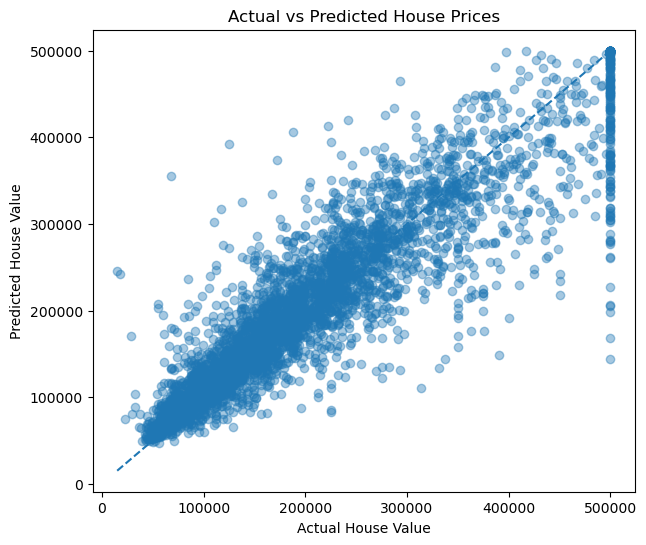

In [91]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    rf_small_pred,
    alpha=0.4
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")

minimum = min(
    y_test.min(),
    rf_small_pred.min()
)

maximum = max(
    y_test.max(),
    rf_small_pred.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.show()

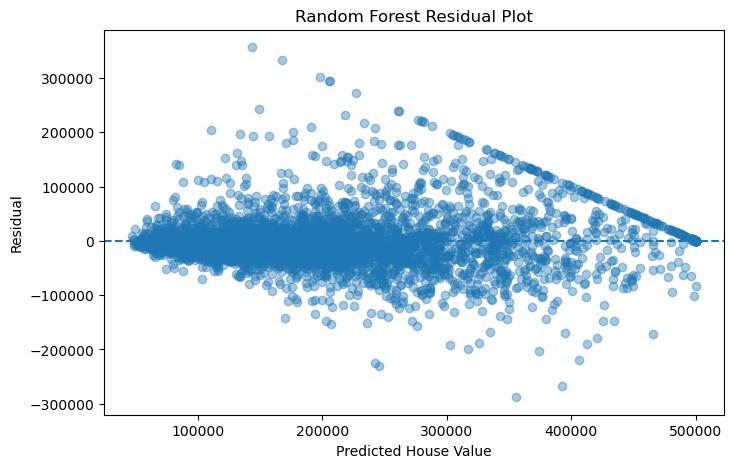

In [106]:
residuals = y_test - rf_small_pred

plt.figure(figsize=(8, 5))

plt.scatter(rf_small_pred,residuals,alpha=0.4)

plt.axhline(y=0,linestyle="--")

plt.xlabel("Predicted House Value")
plt.ylabel("Residual")
plt.title("Random Forest Residual Plot")

plt.show()

In [105]:
fitted_preprocessor = (rf_small_pipeline
    .named_steps["preprocessor"]
)

num_feature_names = numeric_features

cat_feature_names = (fitted_preprocessor.named_transformers_["cat"].named_steps["encoder"]
    .get_feature_names_out(categorical_features))

feature_names = np.concatenate([
    num_feature_names,
    cat_feature_names])

final_rf_model = (
    rf_small_pipeline
    .named_steps["model"])

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance":
        final_rf_model.feature_importances_})

feature_importance = (feature_importance.sort_values("Importance",ascending=False))

print(feature_importance.head(15))

                       Feature  Importance
7                median_income    0.490796
9       ocean_proximity_INLAND    0.140539
0                    longitude    0.105517
1                     latitude    0.101586
2           housing_median_age    0.052323
5                   population    0.032167
4               total_bedrooms    0.024037
3                  total_rooms    0.023146
6                   households    0.018655
12  ocean_proximity_NEAR OCEAN    0.006397
8    ocean_proximity_<1H OCEAN    0.003686
11    ocean_proximity_NEAR BAY    0.000741
10      ocean_proximity_ISLAND    0.000411


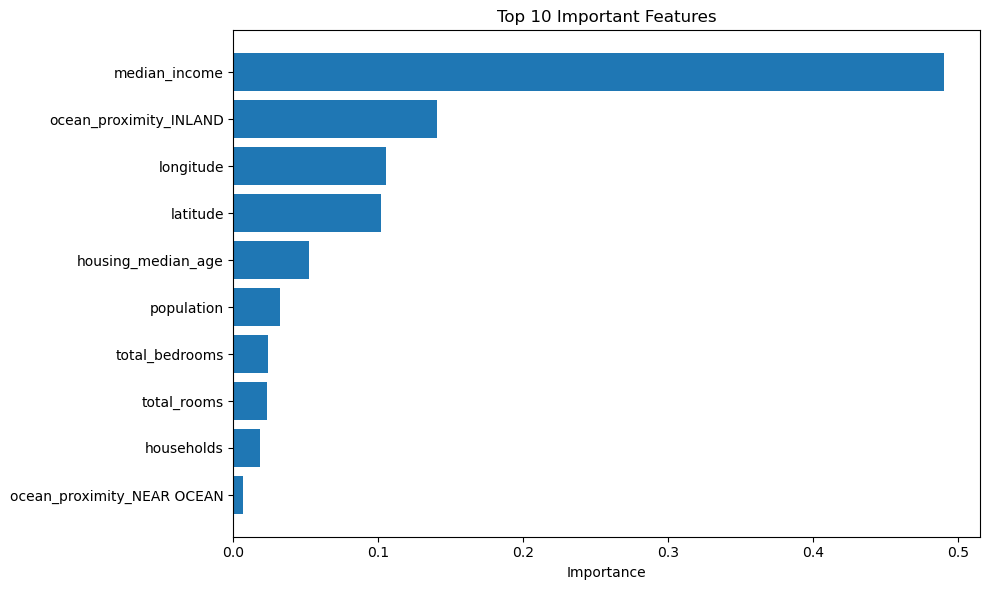

In [95]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"][::-1],top_features["Importance"][::-1])
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [107]:
fitted_preprocessor = rf_small_pipeline.named_steps["preprocessor"]

num_feature_names = numeric_features

cat_feature_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features))

feature_names = np.concatenate([
    num_feature_names,
    cat_feature_names])

final_rf_model = rf_small_pipeline.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False)

print(feature_importance.head(15))

                       Feature  Importance
7                median_income    0.490796
9       ocean_proximity_INLAND    0.140539
0                    longitude    0.105517
1                     latitude    0.101586
2           housing_median_age    0.052323
5                   population    0.032167
4               total_bedrooms    0.024037
3                  total_rooms    0.023146
6                   households    0.018655
12  ocean_proximity_NEAR OCEAN    0.006397
8    ocean_proximity_<1H OCEAN    0.003686
11    ocean_proximity_NEAR BAY    0.000741
10      ocean_proximity_ISLAND    0.000411
